<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 6: Complex Numbers

<ul>
    <li><a href="#learn" style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>
    <li><a href="#background_complex" style="color:#1B5E20;"><strong>Background:</strong> Why Complex Numbers Matter</a>    
    <li><a href="#complex_plane" style="color:black;">Complex Numbers and the Complex Plane</a></li>
    <li><a href="#polar" style="color:black;">Polar Representation</a></li>
    <li><a href="#operations" style="color:black;">Complex Arithmetic and Its Geometry</a></li>
    <li><a href="#polarplot" style="color:black;">Visualizing Complex Numbers in Polar Coordinates</a></li>
    <li><a href="#exercise_rotate" style="color:#006064;"><strong>Exercise 1:</strong> Rotating Complex Numbers</a></li>
    <li><a href="#background_polynomials" style="color:#1B5E20;"><strong>Background:</strong> Polynomial Roots and the Fundamental Theorem of Algebra</a></li>    
    <li><a href="#exercise_polynomial" style="color:#006064;"><strong>Exercise 2:</strong> Visualizing Polynomial Roots</a></li>
    <li><a href="#background_mandelbrot" style="color:#1B5E20;"><strong>Background:</strong> The Mandelbrot Set and Complexity from a Simple Rule</a></li>
    <li><a href="#exercise_mandelbrot" style="color:#006064;"><strong>Exercise 3:</strong> Approximating the Mandelbrot Set</a></li>
</ul>

<a id="learn"></a>
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#E65100; margin-top:0;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
A <strong>complex number</strong> combines a real part and an imaginary part. Complex numbers extend the real number system and provide a natural language for describing rotations, oscillations, and polynomial equations. They also form the mathematical foundation for complex exponentials and <strong>Fourier analysis</strong>, which will be studied in later units. In this unit, we introduce complex numbers in Python and interpret them geometrically as points and vectors in the <strong>complex plane</strong>. We examine their Cartesian and polar representations and study how arithmetic operations affect their length and direction. After completing this unit, you should be able to:
</p>

<ul style="color:#E65100;">
<li>Represent complex numbers in Python and determine their real and imaginary parts.</li>
<li>Interpret complex numbers as points and vectors in the complex plane.</li>
<li>Convert between Cartesian and polar representations using modulus and angle.</li>
<li>Perform complex arithmetic and explain its geometric meaning.</li>
<li>Visualize complex numbers in Cartesian and polar coordinate systems.</li>
<li>Use complex numbers to explore polynomial roots and iterative processes.</li>
</ul>

<p style="color:#E65100;">
The unit contains three exercises:
</p>

<ul style="color:#E65100;">
<li><a href="#exercise_rotate">Exercise 1</a>: Construct, rotate, and visualize complex numbers.</li>
<li><a href="#exercise_polynomial">Exercise 2</a>: Compute and visualize polynomial roots.</li>
<li><a href="#exercise_mandelbrot">Exercise 3</a>: Approximate and visualize the Mandelbrot set.</li>
</ul>

<p style="color:#E65100; margin-bottom:0;">
The first two exercises develop the central concepts of the unit. The third is a more advanced playground combining complex arithmetic, iteration, and the visualization techniques introduced in <a href="PCP_05_vis.html">Unit 5</a>.
</p>

</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
import matplotlib.pyplot as plt

# --- Custom utilities (Unit 6) ---
from libpcp.unit06 import (
    exercise_rotate,
    exercise_polynomial,
    exercise_mandelbrot,
    exercise_mandelbrot_fancy
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id="background_complex"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Why Complex Numbers Matter
</h2>

<p style="color:#1B5E20;">
A <strong>complex number</strong> combines two real quantities: a real part and an imaginary part. Here, the word <strong>complex</strong> means that the number is composed of these two parts, not that it must be complicated. Introducing the imaginary unit $i$, defined by $i^2=-1$, allows every complex number to be written as $z=a+ib$ with $a,b\in\mathbb{R}$. Numbers of the form $ib$ are called <strong>purely imaginary</strong>. The real numbers occur as the special case $b=0$. The term <strong>imaginary</strong> may suggest something invented without practical meaning. In fact, these numbers emerged from concrete mathematical problems. During the sixteenth century, mathematicians encountered square roots of negative numbers while solving polynomial equations. The word <strong>imaginary</strong> was introduced by <a href="https://en.wikipedia.org/wiki/Ren%C3%A9_Descartes">René Descartes</a>, originally reflecting the skepticism with which these unfamiliar numbers were viewed. The symbol $i$, derived from <strong>imaginary</strong>, was later established in mathematical notation through the work of Euler.
</p>

<p style="color:#1B5E20;">
The set of complex numbers is denoted by $\mathbb{C}$, and the notation $z\in\mathbb{C}$ states that $z$ is a complex number. Since every real number is also a complex number with imaginary part zero, $\mathbb{R}\subseteq\mathbb{C}$. Extending $\mathbb{R}$ to $\mathbb{C}$ makes equations such as $z^2+1=0$ solvable and gives polynomial equations a more complete and uniform theory. Further information about their properties and history can be found in the article on <a href="https://en.wikipedia.org/wiki/Complex_number">complex numbers</a>. Electrical engineering commonly uses $j$ instead of $i$ because the letter $i$ is already used for electric current. Python uses the same notation for complex literals. Mathematics may write $1.5+0.8i$, while Python writes <code>1.5 + 0.8j</code>. If the two components are stored in variables <code>a</code> and <code>b</code>, the same number can be constructed using <code>a + b*1j</code>.
</p>

<p style="color:#1B5E20;">
The importance of complex numbers becomes especially clear through their geometry. A nonzero complex number has a length and a direction, described by its modulus and angle. Multiplication can <strong>scale and rotate</strong> at the same time. This makes many relationships between sine and cosine natural consequences of complex arithmetic rather than separate trigonometric formulas. Complex numbers are therefore a natural language for waves and signals. They keep the <strong>amplitude</strong> and <strong>phase</strong> of an oscillation together in a single quantity and provide a compact way to describe how oscillations are shifted and combined. This becomes central in Fourier analysis, where signals are represented using complex oscillations with different frequencies. We will take the next step in <a href="PCP_07_exp.html">Unit 7</a>, where the complex exponential connects multiplication, rotation, sine, and cosine. Complex numbers may have entered mathematics under the suspicious name <strong>imaginary</strong>, but their talent is thoroughly practical: <strong>they turn oscillation and rotation into arithmetic.</strong>
</p>
</div>

<a id="complex_plane"></a>
## Complex Numbers and the Complex Plane

Every complex number $c\in\mathbb{C}$ can be written in **Cartesian form** as $c=a+ib$, where $a,b\in\mathbb{R}$ and the imaginary unit satisfies $i^2=-1$. The number $a=\operatorname{Re}(c)$ is called the **real part**, while $b=\operatorname{Im}(c)$ is called the **imaginary part**. The imaginary part is the real-valued coefficient of $i$, not the complete imaginary term. For example, if $c=1.5+0.8i$, then $\operatorname{Re}(c)=1.5$ and $\operatorname{Im}(c)=0.8$, rather than $0.8i$.

Python represents the imaginary unit using `j` instead of $i$. A coefficient must be attached to it, so the imaginary unit itself is written as `1j`. A complex number can be constructed either directly or with the built-in function `complex()`. NumPy provides `np.real()` and `np.imag()` for extracting its two components:

In [2]:
a = 1.5  # Real part
b = 0.8  # Imaginary part

c = a + b * 1j       # Direct construction
c2 = complex(a, b)   # Construction using the complex() constructor

print('c: ', c,  ', type:', type(c))
print('c2:', c2, ', type:', type(c2))
print('Real part:     ', np.real(c))
print('Imaginary part:', np.imag(c))

c:  (1.5+0.8j) , type: <class 'complex'>
c2: (1.5+0.8j) , type: <class 'complex'>
Real part:      1.5
Imaginary part: 0.8


The two components $a$ and $b$ of $c=a+ib$ also serve as its coordinates in the **complex plane**. We identify

$$
c\in\mathbb{C}
\quad\longleftrightarrow\quad
\bigl(\operatorname{Re}(c),\operatorname{Im}(c)\bigr)
=(a,b)\in\mathbb{R}^2,
$$

where $\mathbb{R}^2$ denotes the set of all ordered pairs of real numbers. The expression $c=a+ib$, or equivalently the coordinate pair $(a,b)$, is called the **Cartesian representation** of $c$. The horizontal coordinate is shown on the **real axis**, while the vertical coordinate is shown on the **imaginary axis**.


The same complex number can be displayed as an **arrow** from the origin $(0,0)$ to the point $(a,b)$. The point representation emphasizes its position, while the arrow emphasizes its **length** and **direction**, leading naturally to the polar representation introduced in the next section. In the following code, `create_complex_plane()` prepares a figure with suitable axes, and `plot_complex_vector()` draws the arrow associated with a complex number. We will reuse both helper functions when visualizing complex arithmetic.


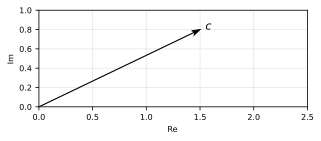

In [3]:
def create_complex_plane(figsize=(4.5, 2),
                         xlim=(0, 1), ylim=(0, 1)):
    """Create a figure for visualizing complex numbers.

    Args:
        figsize: Figure width and height in inches.
        xlim: Limits of the real axis.
        ylim: Limits of the imaginary axis.
    """
    plt.figure(figsize=figsize, layout='tight')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(r'$\operatorname{Re}$')
    plt.ylabel(r'$\operatorname{Im}$')
    plt.grid(alpha=0.3)
    plt.gca().set_axisbelow(True)    

def plot_complex_vector(c, start=0, color='black', linestyle='-'):
    """Plot the complex vector c beginning at start.

    Args:
        c: Complex number representing the vector.
        start: Complex number representing its starting point.
        color: Arrow color.
        linestyle: Arrow line style.

    Returns:
        Created Matplotlib arrow.
    """
    return plt.arrow(
        np.real(start), np.imag(start),
        np.real(c), np.imag(c),
        color=color, linestyle=linestyle,
        head_width=0.05, overhang=0.3,
        length_includes_head=True,
        zorder=3,        
    )


c = 1.5 + 0.8j

create_complex_plane(xlim=(0, 2.5), ylim=(0, 1))
plot_complex_vector(c)
plt.text(np.real(c) + 0.05, np.imag(c), '$c$', fontsize=11);

<a id="polar"></a>

## Polar Representation

The Cartesian representation describes a complex number through its horizontal and vertical components. In many applications, however, it is more natural to describe the corresponding arrow through its length and direction. This leads to the **polar representation**. Let $c=a+ib\neq0$. The **modulus**, also called the **absolute value**, is the length of the arrow and therefore its distance from the origin:

$$
r:=|c|=\sqrt{a^2+b^2}.
$$

The **argument** of $c$ is the angle $\gamma$ from the positive real axis to the arrow representing $c$:

$$
\gamma:=\arg(c).
$$

Unless stated otherwise, angles are measured in **radians**. A complete turn corresponds to $2\pi$ radians, so $\gamma$ and $\gamma+2\pi k$ describe the same direction for every $k\in\mathbb{Z}$. To obtain one standard value, we choose the **principal argument** in the interval $(-\pi,\pi]$. Since $2\pi$ radians correspond to $360^\circ$, an angle can be converted to degrees using

$$
\gamma_{\mathrm{deg}}=\frac{180}{\pi}\,\gamma.
$$

For $c=0$, the modulus is zero, but no unique direction and therefore no argument exists. The Cartesian components can be recovered from the modulus and argument using

$$
a=r\cos(\gamma),
\qquad
b=r\sin(\gamma).
$$

Consequently, the polar form of the complex number is

$$
c=r\bigl(\cos(\gamma)+i\sin(\gamma)\bigr).
$$

The Cartesian representation therefore uses the pair $(a,b)$, while the polar representation of a nonzero complex number uses the pair $(r,\gamma)$. NumPy provides the corresponding functions: `np.abs(c)` computes the modulus, `np.angle(c)` computes the principal argument in radians, and `np.rad2deg()` converts the angle to degrees:

c: (1.5+0.8j)
r = |c|: 1.700000
Argument in radians: 0.489957
Argument in degrees: 28.072487


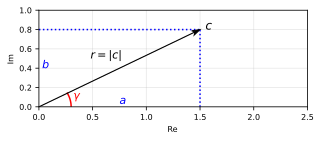

In [4]:
c = 1.5 + 0.8j
a, b = np.real(c), np.imag(c)
r = np.abs(c)
argument = np.angle(c)
argument_degrees = np.rad2deg(argument)

print(f'c: {c}')
print(f'r = |c|: {r:.6f}')
print(f'Argument in radians: {argument:.6f}')
print(f'Argument in degrees: {argument_degrees:.6f}')

create_complex_plane(xlim=(0, 2.5), ylim=(0, 1))
plot_complex_vector(c)

# Cartesian components
plt.plot([0, a], [b, b], color='blue', linestyle=':')
plt.plot([a, a], [0, b], color='blue', linestyle=':')

# Argument
arc = np.linspace(0, argument, 30)
plt.plot(0.3 * np.cos(arc), 0.3 * np.sin(arc), color='red')

# Labels
plt.text(a + 0.05, b, '$c$', fontsize=12)
plt.text(a / 2, 0.03, '$a$', color='blue', fontsize=11)
plt.text(0.03, b / 2, '$b$', color='blue', fontsize=11)
plt.text(0.48, 0.50, '$r=|c|$', fontsize=11)
plt.text(0.32, 0.08, r'$\gamma$', color='red', fontsize=11);

<a id="operations"></a>
## Complex Arithmetic and Its Geometry

Complex numbers can be added, multiplied, conjugated, and divided using algebraic rules based on $i^2=-1$. Their representation in the complex plane gives these operations an additional geometric meaning. Addition combines vectors, while multiplication changes both modulus and argument. We begin with addition. Let $c_1=a_1+ib_1$ and $c_2=a_2+ib_2$ be two complex numbers. Their sum is obtained by adding the real and imaginary parts separately:

$$
c_1+c_2= (a_1+ib_1) + (a_2+ib_2) = (a_1+a_2)+i(b_1+b_2).
$$

In the complex plane, this corresponds to ordinary vector addition. If the arrows representing $c_1$ and $c_2$ begin at the origin, their sum forms the diagonal of the parallelogram constructed from the two vectors. The following example visualizes this relationship:

c1 + c2 = (1.3-0.3j) + (0.3+0.5j) = (1.6+0.2j)


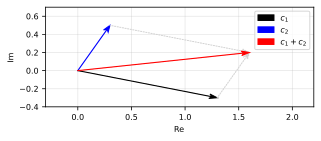

In [5]:
c1 = 1.3 - 0.3j
c2 = 0.3 + 0.5j
c_sum = c1 + c2
print(f'c1 + c2 = {c1} + {c2} = {c_sum}')

create_complex_plane(xlim=(-0.3, 2.2), ylim=(-0.4, 0.7))
v1 = plot_complex_vector(c1, color='black')
v2 = plot_complex_vector(c2, color='blue')
plot_complex_vector(c1, start=c2, color='lightgray', linestyle=':')
plot_complex_vector(c2, start=c1, color='lightgray', linestyle=':')
v_sum = plot_complex_vector(c_sum, color='red')
plt.legend([v1, v2, v_sum], ['$c_1$', '$c_2$', '$c_1+c_2$']);

Complex addition behaves like vector addition in $\mathbb{R}^2$. Complex multiplication has a more distinctive geometric effect: it changes both the length and the direction of a complex number. For $c_1=a_1+ib_1$ and $c_2=a_2+ib_2$, the product follows from expanding the brackets and using $i^2=-1$:

$$c = c_1 \cdot c_2 = (a_1 + ib_1) \cdot (a_2 + ib_2) := (a_1a_2 - b_1b_2) + i(a_1b_2 + b_1a_2).$$

The geometric meaning becomes particularly clear in polar form. The modulus of the product is the product of the two moduli:

$$
|c_1c_2|=|c_1|\,|c_2|.
$$

The argument of the product is the sum of the two arguments, up to complete turns:

$$
\arg(c_1c_2)
=
\arg(c_1)+\arg(c_2)
\pmod{2\pi}.
$$

Thus, multiplication by $c_2$ scales a complex number by the factor $|c_2|$ and rotates it through the angle $\arg(c_2)$. The following example verifies these relationships numerically and visualizes the two factors and their product:

c1 * c2 = (1-0.5j) * (2.3+0.7j) = (2.65-0.44999999999999996j)


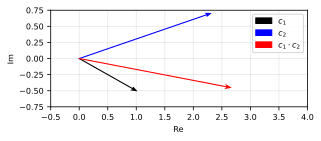

In [6]:
c1 = 1.0 - 0.5j
c2 = 2.3 + 0.7j
c_product = c1 * c2
print(f'c1 * c2 = {c1} * {c2} = {c_product}')

create_complex_plane(xlim=(-0.5, 4.0), ylim=(-0.75, 0.75))
v1 = plot_complex_vector(c1, color='black')
v2 = plot_complex_vector(c2, color='blue')
v_product = plot_complex_vector(c_product, color='red')
plt.legend([v1, v2, v_product], ['$c_1$', '$c_2$', r'$c_1\cdot c_2$']);

The next operation is **complex conjugation**, which changes the sign of the imaginary part while leaving the real part unchanged. For a complex number $c=a+ib$, its conjugate is defined by

$$
\overline{c}:=a-ib.
$$

The conjugate provides compact formulas for recovering the real part, imaginary part, and modulus. It also behaves naturally with respect to addition and multiplication:

\begin{eqnarray*}
a &=& \frac{1}{2} (c+\overline{c}) \\
b &=& \frac{1}{2i} (c-\overline{c}) \\
|c|^2 &=& c\cdot \overline{c}\\
\overline{c_1+c_2} &=& \overline{c_1} + \overline{c_2}\\
\overline{c_1\cdot c_2} &=& \overline{c_1} \cdot \overline{c_2}
\end{eqnarray*}

Geometrically, complex conjugation reflects a number across the real axis. The numbers $c$ and $\overline{c}$ therefore have the same real part and modulus, while their imaginary parts and arguments have opposite signs:

$$
|\,\overline{c}\,|=|c|,
\qquad
\arg(\overline{c})=-\arg(c)
$$

for a nonzero complex number whose argument does not lie on the boundary of the chosen principal interval. NumPy computes the complex conjugate using `np.conj(c)`.


c:              (1.5+0.4j)
Conjugate of c: (1.5-0.4j)


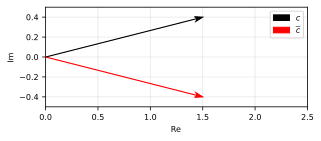

In [7]:
c = 1.5 + 0.4j
c_conjugate = np.conj(c)
print(f'c:              {c}')
print(f'Conjugate of c: {c_conjugate}')

create_complex_plane(xlim=(0, 2.5), ylim=(-0.5, 0.5))
v = plot_complex_vector(c, color='black')
v_conjugate = plot_complex_vector(c_conjugate, color='red')
plt.legend([v, v_conjugate], ['$c$', r'$\overline{c}$']);

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100; margin-bottom:0;">
<strong>Note: Mathematical Notation in Figure Labels.</strong> Matplotlib can display mathematical notation in titles, labels, legends, and other text elements. Expressions enclosed in dollar signs are interpreted using Matplotlib's built-in <a href="https://matplotlib.org/stable/users/explain/text/mathtext.html">Mathtext</a> system. For example, <code>r'$\overline{c}$'</code> produces the symbol $\overline{c}$. The initial <code>r</code> creates a Python <a href="https://docs.python.org/3/reference/lexical_analysis.html#string-and-bytes-literals">raw string</a>, which prevents backslashes from being interpreted as Python escape characters. Raw strings are therefore particularly convenient for mathematical commands such as <code>\overline</code>, <code>\gamma</code>, and <code>\operatorname</code>.
</p>
</div>

For every nonzero complex number $c=a+ib$, there is a unique **multiplicative inverse** $c^{-1}$ satisfying

$$
c\cdot c^{-1}=1.
$$

Using $c\overline{c}=|c|^2=a^2+b^2$, the inverse can be written as

$$
c^{-1}
:=\frac{1}{c}
=\frac{\overline{c}}{c\overline{c}}
=\frac{\overline{c}}{|c|^2}
=\frac{a}{a^2+b^2}
-i\frac{b}{a^2+b^2}.
$$

Geometrically, inversion replaces the modulus by its reciprocal and reverses the argument:

$$
|c^{-1}|=\frac{1}{|c|},
\qquad
\arg(c^{-1})\equiv-\arg(c)\pmod{2\pi}.
$$

The number $c=0$ has no multiplicative inverse because no complex number multiplied by zero can produce $1$. In Python, the inverse of a nonzero complex number is computed directly using `1 / c`.


c: (1.5+0.4j)
c_inverse: (0.6224066390041494-0.16597510373443983j)
c * c_inverse: (1+0j)


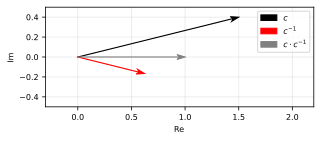

In [8]:
c = 1.5 + 0.4j
c_inverse = 1 / c
c_product = c * c_inverse
print(f'c: {c}')
print(f'c_inverse: {c_inverse}')
print(f'c * c_inverse: {c_product}')

create_complex_plane(xlim=(-0.3, 2.2), ylim=(-0.5, 0.5))
v = plot_complex_vector(c, color='black')
v_inverse = plot_complex_vector(c_inverse, color='red')
v_product = plot_complex_vector(c_product, color='gray')
plt.legend([v, v_inverse, v_product], ['$c$', '$c^{-1}$', r'$c\cdot c^{-1}$']);

Using the multiplicative inverse, division of complex numbers can be defined as multiplication by the inverse of the denominator. Let $c_1=a_1+ib_1$ and $c_2=a_2+ib_2\neq0$. Then

$$
\frac{c_1}{c_2}:=c_1c_2^{-1}=\frac{c_1\overline{c_2}}{|c_2|^2}=\frac{a_1a_2+b_1b_2}{a_2^2+b_2^2}+i\frac{b_1a_2-a_1b_2}{a_2^2+b_2^2}.
$$

The geometric behavior is the reverse of multiplication. The moduli are divided, and the argument of the denominator is subtracted:

$$
\left|\frac{c_1}{c_2}\right|
=\frac{|c_1|}{|c_2|},
\qquad
\arg\left(\frac{c_1}{c_2}\right)
\equiv
\arg(c_1)-\arg(c_2)
\pmod{2\pi}.
$$

Division by zero is undefined because $c_2=0$ has no multiplicative inverse. In Python, division of two nonzero complex numbers is performed using the usual `/` operator.


c1 / c2 = (1.3+0.3j) / (0.8+0.4j) = (1.45-0.35000000000000003j)


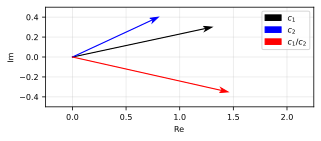

In [9]:
c1 = 1.3 + 0.3j
c2 = 0.8 + 0.4j
c_quotient = c1 / c2
print(f'c1 / c2 = {c1} / {c2} = {c_quotient}')
create_complex_plane(xlim=(-0.25, 2.25), ylim=(-0.5, 0.5))

v1 = plot_complex_vector(c1, color='black')
v2 = plot_complex_vector(c2, color='blue')
v_quotient = plot_complex_vector(c_quotient, color='red')
plt.legend([v1, v2, v_quotient], ['$c_1$', '$c_2$', r'$c_1/c_2$']);

<a id="polarplot"></a>

## Visualizing Complex Numbers in Polar Coordinates

So far, complex numbers have been displayed in the Cartesian complex plane, where the axes represent real and imaginary parts. A **polar plot** uses the polar representation directly: the angular position represents the argument $\arg(c)$, while the radial distance from the origin represents the modulus $|c|$.

This representation is particularly useful for comparing the lengths and directions of complex numbers. It also makes the geometric rules for conjugation, multiplication, and division easier to recognize. The following helper function draws a complex number as an arrow in a polar coordinate system:

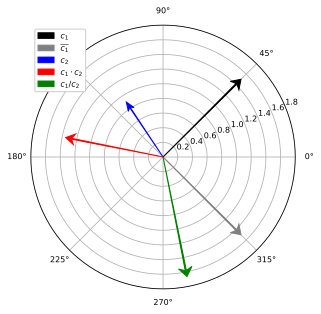

In [10]:
def plot_polar_vector(c, label=None, color='black', linestyle='-'):
    """Plot a complex number as a vector in polar coordinates."""
    angle, radius = np.angle(c), np.abs(c)
    return plt.arrow(
        angle, 0, 0, radius,
        color=color, label=label, linestyle=linestyle,
        width=0.01, head_width=0.12, head_length=0.12,
        overhang=0.3, length_includes_head=True, zorder=3,
    )
    
c_abs = 1.5
c_angle = 45  # In degrees
c_angle_rad = np.deg2rad(c_angle)

a = c_abs * np.cos(c_angle_rad)
b = c_abs * np.sin(c_angle_rad)
c1 = a + b * 1j
c2 = -0.5 + 0.75j

plt.figure(figsize=(4.5, 4.5), layout='tight')
plt.subplot(projection='polar')
plt.gca().set_axisbelow(True)

handles = [
    plot_polar_vector(c1, '$c_1$', 'k'),
    plot_polar_vector(np.conj(c1), r'$\overline{c_1}$', 'gray'),
    plot_polar_vector(c2, '$c_2$', 'b'),
    plot_polar_vector(c1 * c2, r'$c_1\cdot c_2$', 'r'),
    plot_polar_vector(c1 / c2, r'$c_1/c_2$', 'g'),
]

plt.ylim(0, 1.8)
plt.legend(handles=handles, framealpha=1, loc='upper left');

<a id="exercise_rotate"></a>

<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 1: Rotating Complex Numbers</strong>

<p style="color:#006064;">
Multiplication by a complex number of modulus one changes the direction of a complex number without changing its modulus. This exercise uses that geometric property to construct and rotate complex numbers.
</p>

<ul style="color:#006064;">
<li><strong>Construct a complex number:</strong> Create a complex number $c$ with modulus $|c|=1.2$ and argument $\arg(c)=20^\circ$. Convert the angle to radians using <code>np.deg2rad()</code>, and determine the real and imaginary parts using sine and cosine.</li>
<li><strong>Conjugate and invert:</strong> Compute $\overline{c}$ and $c^{-1}$. Display all three numbers in the same plot and compare their moduli and arguments.</li>
<li><strong>Implement a rotation:</strong> Write a function <code>rotate_complex(c, angle)</code> that rotates a complex number <code>c</code> clockwise by <code>angle</code> degrees. Construct the required rotation factor using sine and cosine.</li>
<li><strong>Apply the function:</strong> Rotate $c=1+0.5i$ clockwise by the angles $15^\circ$, $30^\circ$, and $45^\circ$. Plot the original number and all three rotated numbers in the same complex plane.</li>
<li><strong>Interpret the result:</strong> Verify that rotation changes the argument but preserves the modulus. Explain why a clockwise rotation requires subtracting the rotation angle.</li>
</ul>

</div>


In [11]:
# Your Solution

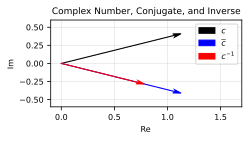

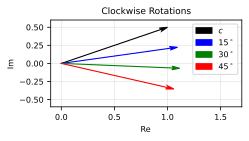

In [12]:
exercise_rotate()

<a id="background_polynomials"></a>

<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: Polynomial Roots and the Fundamental Theorem of Algebra
</h2>

<p style="color:#1B5E20;">
A polynomial of degree $N$ with complex coefficients has the form
$p(z)=p_0z^N+p_1z^{N-1}+\cdots+p_{N-1}z+p_N$, where
$p_0,\ldots,p_N\in\mathbb{C}$ and $p_0\neq0$. A number
$c\in\mathbb{C}$ is called a <strong>root</strong>, or <strong>zero</strong>,
of $p$ if $p(c)=0$. Polynomial equations provide one of the strongest motivations for complex numbers. The equation $z^2-1=0$ has the real roots $z=\pm1$, but $z^2+1=0$ has no real root because the square of a real number cannot be negative. After extending $\mathbb{R}$ to $\mathbb{C}$, the missing roots emerge as $z=\pm i$.
</p>

<p style="color:#1B5E20;">
This is not an isolated success. The <a href="https://en.wikipedia.org/wiki/Fundamental_theorem_of_algebra"><strong>fundamental theorem of algebra</strong></a> states that every nonconstant polynomial with complex coefficients has a complex root. More precisely, a polynomial of degree $N$ has exactly $N$ complex roots when repeated roots are counted according to their <strong>multiplicity</strong>. It can therefore be written as
$$
p(z)=p_0(z-c_1)(z-c_2)\cdots(z-c_N),
$$
where $c_1,\ldots,c_N$ are its roots, including repetitions. For example,
$$
p(z)=z^3-3z+2=(z-1)^2(z+2)
$$
has degree three and the roots $c_1=1$, $c_2=1$, and $c_3=-2$. Thus, the root $1$ has multiplicity two. The theorem does not imply that the roots are distinct or that they can be computed by a simple formula. It guarantees that every polynomial with complex coefficients can be factored completely into linear factors over $\mathbb{C}$. This property is expressed by saying that the complex number system is <strong>algebraically closed</strong>.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
The coefficients of a polynomial may impose additional structure on its roots. If all coefficients are real, every nonreal root occurs together with its complex conjugate. Root plots of real polynomials are therefore symmetric with respect to the real axis. Particular polynomial forms create further geometric patterns. The roots of $z^N-1$, for example, are equally spaced on the unit circle. Visualizing roots makes such patterns easier to recognize. It can also illustrate their numerical sensitivity: repeated or closely clustered roots may move noticeably when the coefficients change only slightly. The next exercise explores both phenomena.
</p>

</div>


<a id="exercise_polynomial"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 2: Visualizing Polynomial Roots</strong>

<p style="color:#006064;">
NumPy represents a polynomial $p(z)=p_0z^N+p_1z^{N-1}+\cdots+p_{N-1}z+p_N$ of degree $N$, where $p_0\neq0$, by a one-dimensional array containing its coefficients in descending order of powers: <code>p = np.array([p_0, p_1, ..., p_N])</code>.
The command <code>roots = np.roots(p)</code> then returns an array containing its roots.
</p>

<ul style="color:#006064;">
<li><strong>Implement the visualization:</strong> Write a function <code>visualize_roots(p)</code> that computes the roots using <a href="https://numpy.org/doc/stable/reference/generated/numpy.roots.html"><code>np.roots()</code></a> and displays them in the complex plane using <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html"><code>plt.scatter()</code></a>. Plot the real parts horizontally and the imaginary parts vertically.</li>
<li><strong>Apply the function:</strong> Construct the coefficient array for each polynomial below and visualize its roots.
  <ul>
  <li>$p(z)=z^2-2$</li>
  <li>$p(z)=z^2+2$</li>
  <li>$p(z)=z^8-1$</li>
  <li>$p(z)=z^8+z^7+z^6$</li>
  <li>$p(z)=z^8+z^7+z^6+10^{-6}$</li>
  <li>$p(z)=z^3+(1-2i)z^2+3$</li>
  </ul>
</li>
</ul>

<p style="color:#006064; margin-bottom:0;">
Compare the resulting patterns and relate them to the algebraic forms of the polynomials. Pay particular attention to the fourth and fifth examples: how does the small change in the constant coefficient affect the roots near the origin, and what does this reveal about the numerical sensitivity of repeated or closely clustered roots?
</p>
</div>

In [13]:
# Your Solution

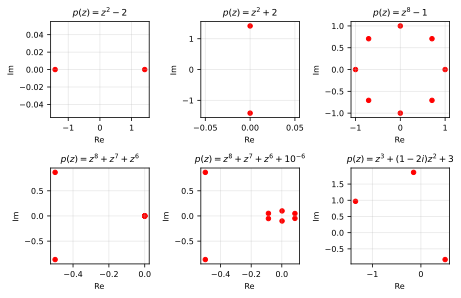

In [14]:
exercise_polynomial()

<a id="background_mandelbrot"></a>
<div style="
  background-color: #C8E6C9A0;
  border: 1px solid #81C784A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<h2 style="color:#1B5E20; margin-top:0;">
Background: The Mandelbrot Set and Complexity from a Simple Rule
</h2>

<div style="
  float:right;
  width:200px;
  max-width:45%;
  margin-left:20px;
  margin-bottom:10px;
">
<a href="https://en.wikipedia.org/wiki/Mandelbrot_set">
<img src="data/PCP_fig_mandelbrot.png"
     style="display:block; width:100%; height:auto;"
     alt="Visualization of the Mandelbrot set">
</a>
</div>

<p style="color:#1B5E20;">
One of the most remarkable lessons of mathematics is that a simple rule can produce astonishing complexity. The <a href="https://en.wikipedia.org/wiki/Mandelbrot_set"><strong>Mandelbrot set</strong></a> is perhaps the best-known example. Its construction uses only complex numbers, squaring, addition, and repetition. Nevertheless, its boundary reveals progressively finer and recursively structured detail under magnification. This infinitely intricate boundary is a <a href="https://en.wikipedia.org/wiki/Fractal_curve"><strong>fractal curve</strong></a>. The Mandelbrot set is a set of <strong>parameters</strong>. Each point $c$ in the complex plane defines its own iteration
$$
z_0=0,
\qquad
z_{k+1}=z_k^2+c.
$$
Some choices of $c$ produce bounded sequences, while others eventually escape toward infinity. The Mandelbrot set contains precisely those parameters for which the sequence remains <strong>bounded</strong>. Thus, every pixel in its visualization represents a separate numerical experiment.
</p>

<p style="color:#1B5E20;">
A computer cannot perform infinitely many iterations or examine every point of the complex plane. The images we create are therefore approximations based on a finite grid, a maximum number of iterations, and a rule for detecting escape. In a binary image, points that appear to belong to the set are commonly shown in black. More elaborate images assign colors to points outside the set according to how quickly their sequences escape. The colors are not part of the mathematical definition, but they expose the structure surrounding its boundary. The Mandelbrot set has become famous far beyond mathematics. Its popularity comes partly from its <strong>visual beauty</strong> and partly from the surprising way in which a very short rule generates an apparently inexhaustible landscape. Interactive visualizations allow us to zoom into the boundary and discover new spirals, branches, miniature structures, and variations at increasingly fine scales.
</p>

<p style="color:#1B5E20; margin-bottom:0;">
This example brings together <a href="PCP_04_control.html">loops and stopping criteria from Unit 4</a>, <a href="PCP_05_vis.html">arrays and visualization from Unit 5</a>, and complex arithmetic from Unit 6. The next exercise turns these elementary ingredients into one of the most recognizable images in mathematics. <strong>Be careful, however: exploring the Mandelbrot set can become strangely addictive. Remember that there are still more units to complete.</strong>
</p>

<div style="clear:both;"></div>
</div>

<a id="exercise_mandelbrot"></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">

<strong style="color:#006064; display:block; break-after:avoid; page-break-after:avoid;">Exercise 3: Approximating the Mandelbrot Set</strong>

<p style="color:#006064;">
In this exercise, you will approximate the Mandelbrot set introduced above. Each point $c=a+ib$ in a finite region of the complex plane is tested by starting with $z_0=0$ and applying the iteration
$$
z_{k+1}=z_k^2+c.
$$
The result of each test becomes one entry of a two-dimensional image.
</p>

<ul style="color:#006064;">
<li><strong>Create the coordinate grid:</strong> Use the ranges $a\in[-2,1]$ and $b\in[-1.2,1.2]$ with the spacing $\Delta a=\Delta b=0.01$. Construct one-dimensional coordinate arrays and use <code>np.meshgrid()</code> to form the matrices <code>A</code> and <code>B</code>. The matrix <code>C = A + 1j * B</code> then contains the corresponding complex numbers.</li>

<li><strong>Test each parameter:</strong> For every entry <code>c</code> of <code>C</code>, set <code>z = 0</code> and repeatedly update it using <code>z = z**2 + c</code>. Perform at most $K=100$ iterations.</li>

<li><strong>Detect escape:</strong> Stop the iteration as soon as <code>abs(z) &gt; 2</code>. Once this limit has been crossed, the sequence is guaranteed to escape toward infinity, so the corresponding value of $c$ does not belong to the Mandelbrot set.</li>

<li><strong>Construct the approximation:</strong> Create a binary array <code>indicator</code> with the same shape as <code>C</code>. Assign the value <code>0</code> to points that escape and <code>1</code> to points that remain within the escape radius during all $K$ iterations. This array approximates the indicator function $\chi:\mathbb{C}\to\{0,1\}$. A point classified as <code>1</code> may still escape after more than $K$ iterations.</li>

<li><strong>Write a reusable function:</strong> Combine these steps in a function <code>approximate_mandelbrot()</code> that returns the coordinate arrays and the binary indicator array.</li>

<li><strong>Visualize the result:</strong> Display <code>indicator</code> using <code>plt.imshow()</code> with <code>cmap='gray_r'</code>, <code>origin='lower'</code>, and <code>extent=[-2, 1, -1.2, 1.2]</code>. Label the axes with the real and imaginary parts of $c$.</li>

<li><strong>Explore the boundary:</strong> Increase the maximum number of iterations or use a finer coordinate grid and observe which parts of the image change. You may also investigate a smaller region near the boundary, for example around $c=-0.74+0.13i$, where additional structures become visible under magnification.</li>
</ul>

</div>

In [15]:
# Your Solution

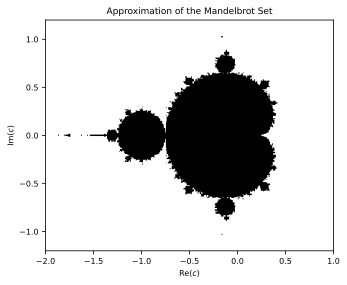

In [16]:
exercise_mandelbrot()

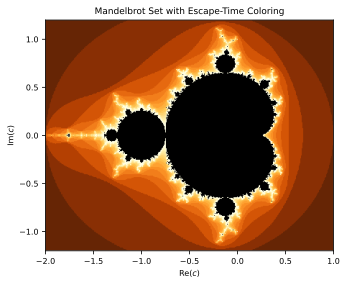

In [17]:
exercise_mandelbrot_fancy()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>